In [1]:
!git clone https://github.com/faranbutt/CGCC.git

Cloning into 'CGCC'...
remote: Enumerating objects: 563, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 563 (delta 46), reused 45 (delta 30), pack-reused 481 (from 1)
Receiving objects: 100% (563/563), 1.92 MiB | 14.15 MiB/s, done.
Resolving deltas: 100% (213/213), done.


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.4 MB/s eta 0:00:00


In [62]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.data.data import DataEdgeAttr
from torch_geometric.nn import SAGEConv,  global_mean_pool, global_max_pool, global_add_pool, GATConv
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import seaborn as sns
import os
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import networkx as nx
import math
%matplotlib inline


In [4]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(25)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [6]:
train_path = Path('CGCC/data/train')
test_path = Path('CGCC/data/test')
train_labels_path = Path('CGCC/data/train_labels.csv')

In [7]:
labels_df = pd.read_csv(train_labels_path)

In [8]:
labels_df.head()

,filename,target
0,Washington_DC_USA.pkl,2
1,Mannheim_Germany.pkl,1
2,Addis_Ababa_Ethiopia.pkl,2
3,Atlanta_Georgia_USA.pkl,2
4,Papeete_French_Polynesia.pkl,0


In [9]:
print("Dataset Overview")
print(f"Training samples: {len(labels_df)}")
print("Class Distrbution")
print(labels_df['target'].value_counts().sort_index())


Dataset Overview
Training samples: 84
Class Distrbution
target
0    22
1    26
2    36
Name: count, dtype: int64


In [10]:
def load_graph(filename):
  with open(filename,'rb') as f:
    G = pickle.load(f)
  return G

In [11]:
train_path

PosixPath('CGCC/data/train')

In [12]:
all_stats = []
for idx, row in labels_df.iterrows():
    filename = train_path / row['filename']
    G = load_graph(filename)
    stats = {
        'num_nodes': G.number_of_nodes(),
        'num_edges': G.number_of_edges(),
        'density': nx.density(G),
        'avg_degree': 2 * G.number_of_edges() / G.number_of_nodes() if G.number_of_nodes() > 0 else 0,
    }
    stats['num_components'] = nx.number_connected_components(G)
    degrees = [d for n, d in G.degree()]
    stats['degree_mean'] = np.mean(degrees)
    stats['degree_std'] = np.std(degrees)
    stats['degree_min'] = np.min(degrees)
    stats['degree_max'] = np.max(degrees)

    try:
        if nx.is_connected(G):
            stats['diameter'] = nx.diameter(G)
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            subgraph = G.subgraph(largest_cc)
            stats['diameter'] = nx.diameter(subgraph)
    except:
        stats['diameter'] = -1

    stats['filename'] = row['filename']
    stats['city_type'] = row['target']
    stats['city_name'] = row['filename'].replace('.pkl', '')
    all_stats.append(stats)

In [13]:
stats_df = pd.DataFrame(all_stats)
stats_df.head()

,num_nodes,num_edges,density,avg_degree,num_components,degree_mean,degree_std,degree_min,degree_max,diameter,filename,city_type,city_name
0,41,56,0.068293,2.731707,1,2.731707,0.625647,1,4,18,Washington_DC_USA.pkl,2,Washington_DC_USA
1,143,212,0.020881,2.965035,1,2.965035,0.926778,1,4,24,Mannheim_Germany.pkl,1,Mannheim_Germany
2,169,230,0.016202,2.721893,1,2.721893,0.729468,1,4,23,Addis_Ababa_Ethiopia.pkl,2,Addis_Ababa_Ethiopia
3,100,152,0.030707,3.040000,1,3.040000,0.978979,1,5,15,Atlanta_Georgia_USA.pkl,2,Atlanta_Georgia_USA
4,216,273,0.011757,2.527778,1,2.527778,1.053726,1,5,22,Papeete_French_Polynesia.pkl,0,Papeete_French_Polynesia


In [14]:
summary_stats = stats_df.groupby('city_type').agg({
    'num_nodes': ['mean', 'std', 'min', 'max'],
    'num_edges': ['mean', 'std', 'min', 'max'],
    'density': ['mean', 'std'],
    'avg_degree': ['mean', 'std'],
    'num_components': ['mean', 'std']
}).round(3)
print(summary_stats)

          num_nodes                  num_edges                  density  \
               mean     std min  max      mean     std min  max    mean   
city_type                                                                 
0           130.955  63.601  32  266   180.045  88.125  42  377   0.027   
1           109.577  46.950  31  232   168.731  78.230  43  361   0.033   
2           101.833  44.442  19  183   144.028  64.594  21  258   0.038   

                 avg_degree        num_components       
             std       mean    std           mean  std  
city_type                                               
0          0.017      2.747  0.155            1.0  0.0  
1          0.016      3.035  0.231            1.0  0.0  
2          0.028      2.801  0.195            1.0  0.0  


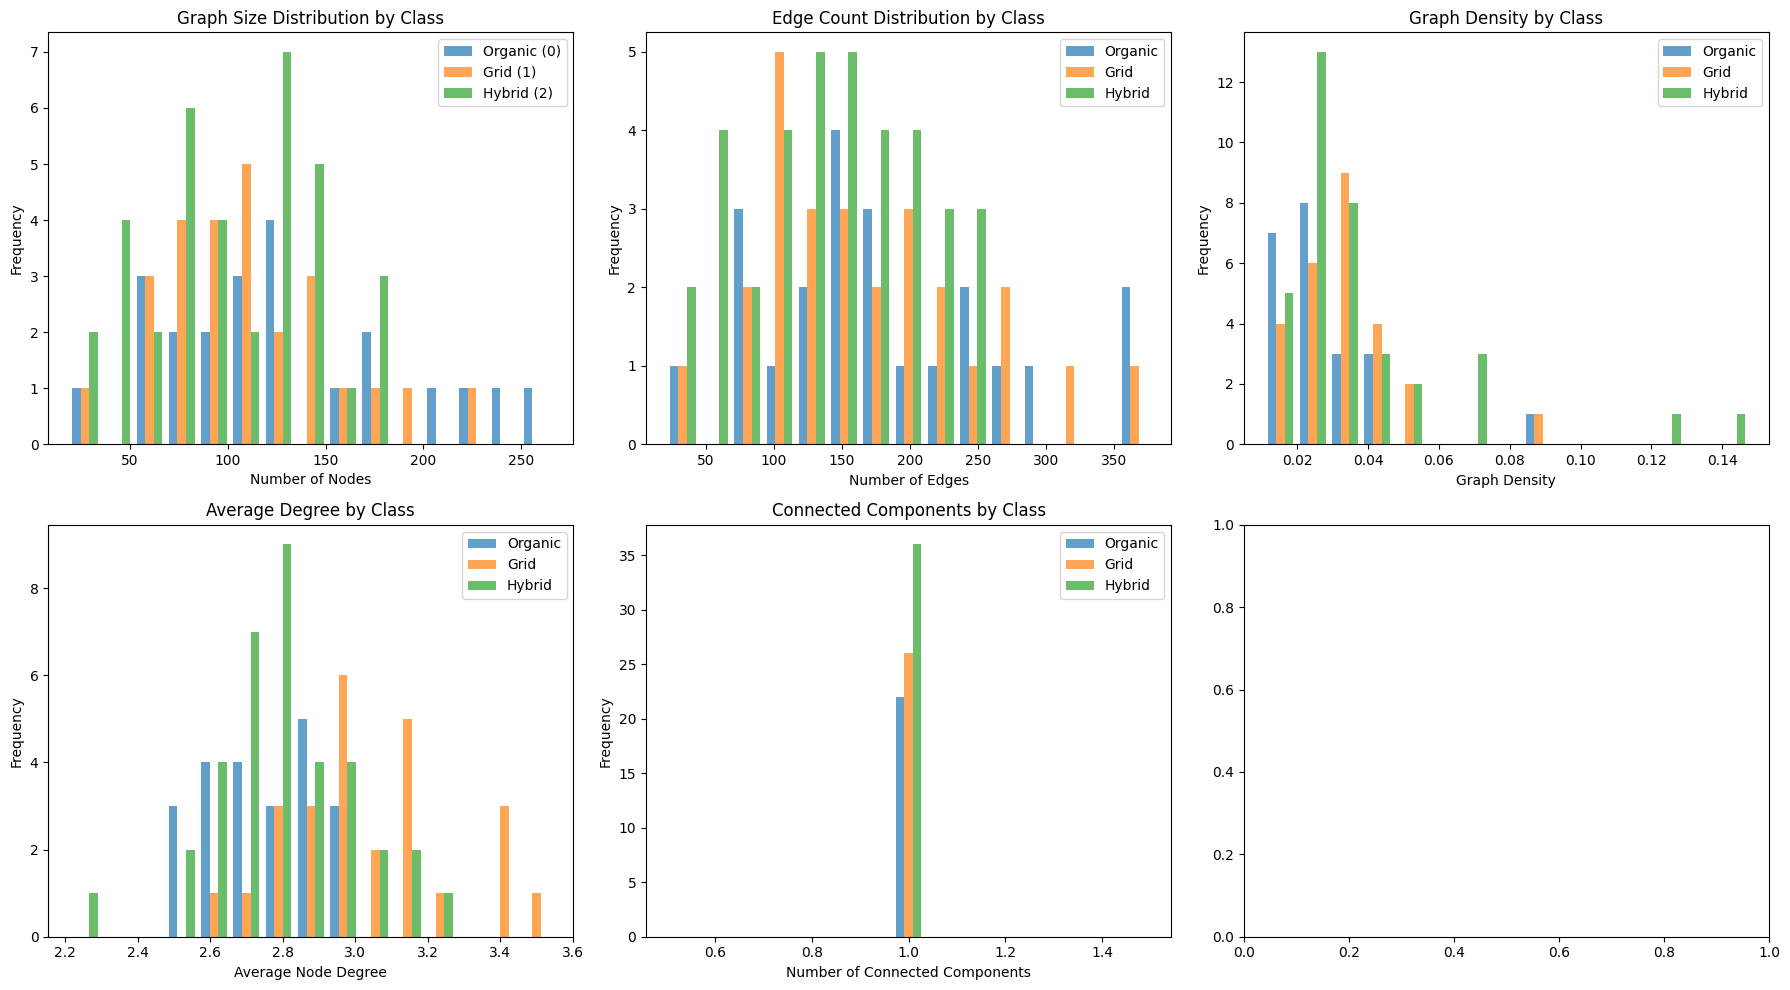

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].hist([stats_df[stats_df['city_type']==i]['num_nodes'] for i in [0,1,2]],
               bins=15, label=['Organic (0)', 'Grid (1)', 'Hybrid (2)'], alpha=0.7)
axes[0, 0].set_xlabel('Number of Nodes')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Graph Size Distribution by Class')
axes[0, 0].legend()

axes[0, 1].hist([stats_df[stats_df['city_type']==i]['num_edges'] for i in [0,1,2]],
               label=['Organic', 'Grid', 'Hybrid'], alpha=0.7, bins=15)
axes[0, 1].set_xlabel('Number of Edges')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Edge Count Distribution by Class')
axes[0, 1].legend()

axes[0, 2].hist([stats_df[stats_df['city_type']==i]['density'] for i in [0,1,2]],
               label=['Organic', 'Grid', 'Hybrid'], alpha=0.7, bins=15)
axes[0, 2].set_xlabel('Graph Density')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Graph Density by Class')
axes[0, 2].legend()

axes[1, 0].hist([stats_df[stats_df['city_type']==i]['avg_degree'] for i in [0,1,2]],
               label=['Organic', 'Grid', 'Hybrid'], alpha=0.7, bins=15)
axes[1, 0].set_xlabel('Average Node Degree')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Average Degree by Class')
axes[1, 0].legend()

axes[1, 1].hist([stats_df[stats_df['city_type']==i]['num_components'] for i in [0,1,2]],
               label=['Organic', 'Grid', 'Hybrid'], alpha=0.7, bins=15)
axes[1, 1].set_xlabel('Number of Connected Components')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Connected Components by Class')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('graph_statistics_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

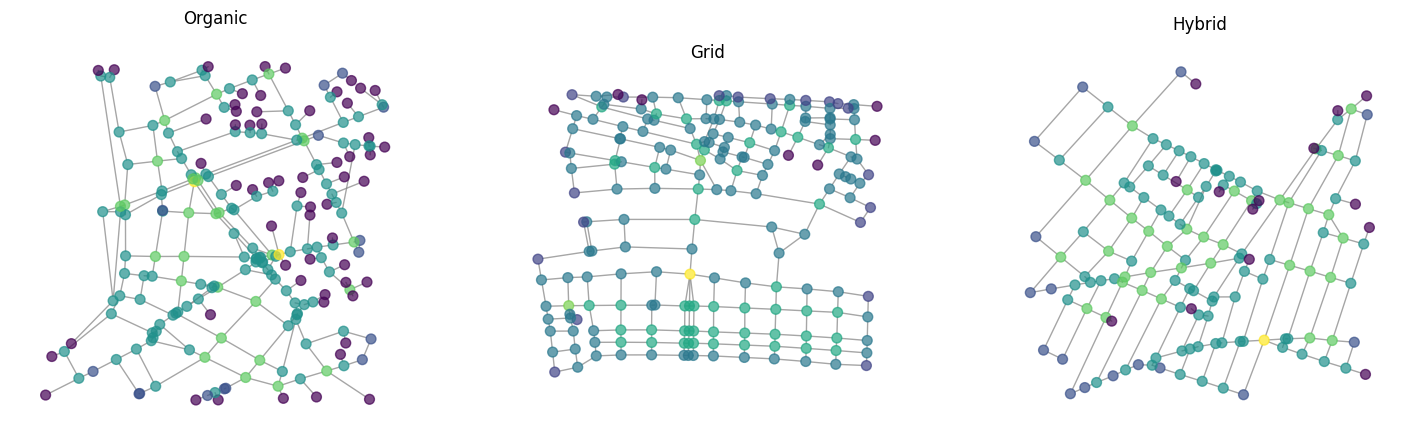

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))
for i, class_label in enumerate([0,1,2]):
    class_samples = stats_df[stats_df['city_type'] == class_label].sample(1, random_state=25)
    filename = train_path / class_samples.iloc[0]['filename']
    G = load_graph(filename)
    class_names = ['Organic', 'Grid', 'Hybrid'] # Fixed from 'Organic, Grid, Hybrid' list error
    pos = {node: (G.nodes[node]['x'], G.nodes[node]['y']) for node in G.nodes()}
    degrees = dict(G.degree())
    node_colors = [degrees[node] for node in G.nodes()]
    nx.draw(G, pos, ax=axes[i], node_color=node_colors, node_size=50,
            edge_color='gray', cmap='viridis', with_labels=False, alpha=0.7)
    axes[i].set_title(class_names[i])
    axes[i].set_aspect('equal')

In [19]:
def compute_edge_angles(G):
  angles = {}
  for node in G.nodes():
    x0,y0 = G.nodes[node]['x'], G.nodes[node]['y']
    neighbor_angles = []
    for neigbor in G.neighbors(node):
      x1,y1  = G.nodes[neigbor]['x'], G.nodes[neigbor]['y']
      dx = x1-x0
      dy = y1-y0
      angle= math.atan2(dy,dx)
      neighbor_angles.append(angle)
    angles[node] = neighbor_angles
  return angles

angles = compute_edge_angles(G)
angles[280164036]

[-2.3034087458036354, -0.6850668380524916]

In [20]:
def extract_node_feat(G):
  if G.is_multigraph():
    G_simple = nx.Graph(G)
  else:
    G_simple = G
  n = G.number_of_nodes()
  degrees = dict(G.degree())
  clustering = nx.clustering(G_simple)
  betweenness = nx.betweenness_centrality(G, normalized=True)
  angles_dict = compute_edge_angles(G)
  angle_mean = {}
  angle_var = {}
  for node, angles in angles_dict.items():
    if len(angles) > 0:
      vectors = np.array([[np.cos(a),np.sin(a)] for a in angles])
      mean_vec = vectors.mean(axis=0)
      mean_angle = np.arctan2(mean_vec[1],mean_vec[0])
      R = np.linalg.norm(mean_vec)
      circ_var = 1-R
    else:
      mean_angle = 0.0
      circ_var = 0.0
    angle_mean[node] = mean_angle
    angle_var[node] = circ_var
  features =  []
  for node in G.nodes():
    feat = [
        G.nodes[node]['x'],
        G.nodes[node]['y'],
        degrees[node],
        clustering[node],
        betweenness[node],
        angle_mean[node],
        angle_var[node]
    ]
    features.append(feat)
  features = np.array(features,dtype=np.float32)
  mean = features.mean(axis = 0,keepdims=True)
  std = features.std(axis=0,keepdims = True) + 1e-8
  return (features - mean) / std
extract_node_feat(G).shape

(142, 7)

In [21]:
def extract_graph_feat(G, global_scaler=None):
  num_nodes =G.number_of_nodes()
  num_edges = G.number_of_edges()
  density = nx.density(G)
  degrees = [d for n,d in G.degree()]
  avg_degree = np.mean(degrees)
  std_degree = np.std(degrees)
  degree_entropy = -np.sum([(d/num_edges)*np.log(d/num_edges) for d in degrees if d > 0])
  G_simple = nx.Graph(G) if G.is_multigraph() else G
  clustering_coeffs = list(nx.clustering(G_simple).values())
  avg_clustering = np.mean(clustering_coeffs)
  components = list(nx.connected_components(G))
  num_components = len(components)
  largest_component_size = max([len(c) for c in components]) if components else 0
  edge_angles = []
  for u,v in G.edges():
    x1,y1 = G.nodes[u]['x'], G.nodes[u]['y']
    x2,y2 = G.nodes[v]['x'], G.nodes[v]['y']
    angle = math.atan2(y2-y1,x2-x1)
    edge_angles.append(angle)

  hist,_ = np.histogram(edge_angles, bins=16, range=(-np.pi, np.pi), density=True)
  global_feats = np.array([num_nodes,num_edges,density,avg_degree, std_degree, degree_entropy,avg_clustering, num_components,largest_component_size / num_nodes] + hist.tolist(), dtype=np.float32)
  if global_scaler is not None:
    global_feats = global_scaler.transform(global_feats.reshape(1,-1)).flatten()
  return global_feats
extract_graph_feat(G)

array([1.42000000e+02, 2.10000000e+02, 2.09769253e-02, 2.95774651e+00,
       8.87100339e-01, 8.42258644e+00, 2.18309853e-02, 1.00000000e+00,
       1.00000000e+00, 1.09134816e-01, 7.27565438e-02, 3.39530557e-01,
       1.81891367e-01, 0.00000000e+00, 1.21260909e-02, 3.75908822e-01,
       1.94017455e-01, 1.81891367e-01, 1.21260909e-02, 4.48665351e-01,
       1.81891367e-01, 0.00000000e+00, 1.21260909e-02, 2.42521822e-01,
       1.81891367e-01], dtype=float32)

In [27]:
def extract_edge_features(G):
  edge_feats = []
  for u,v in G.edges():
    x1,y1 = G.nodes[u]['x'], G.nodes[u]['y']
    x2,y2 = G.nodes[v]['x'], G.nodes[v]['y']
    dx,dy = x2-x1, y2-y1
    length = np.sqrt(dx**2+dy**2)
    angle = math.atan2(dy,dx)
    edge_feats.append([length, np.sin(angle), np.cos(angle)])
  return np.array(edge_feats, dtype=np.float32)

In [35]:
raw_global_feats = []
for i in range(len(labels_df)):
  fname = f"{train_path}/{labels_df.iloc[i]['filename']}"
  with open(fname,'rb') as f:
    G = pickle.load(f)

  G = nx.convert_node_labels_to_integers(G)
  raw_gf = extract_graph_feat(G,global_scaler=None)
  raw_global_feats.append(raw_gf)
raw_global_feats = np.stack(raw_global_feats)

In [36]:
global_scaler = StandardScaler()
global_scaler.fit(raw_global_feats)

StandardScaler()

In [37]:
node_feats_list = []
edge_index_list = []
edge_attr_list = []
y_list = []

In [41]:
for i in range(len(labels_df)):
  fname = f"{train_path}/{labels_df.iloc[i]['filename']}"
  with open(fname, 'rb') as f:
    G = pickle.load(f)
  G = nx.convert_node_labels_to_integers(G)
  node_feats = extract_node_feat(G)
  node_feats_list.append(torch.tensor(node_feats,dtype=torch.float))
  edges = list(G.edges())
  if len(edges) == 0:
    edge_index_list.append(torch.empty((2,0), dtype=torch.long))
    edge_attr_list.append(torch.empty((0,3),dtype=torch.float))
  else:
    edge_index_list.append(torch.tensor(edges,dtype=torch.long).t().contiguous())
    edge_attr = extract_edge_features(G)
    edge_attr_list.append(torch.tensor(edge_attr, dtype=torch.float))
  y_list.append(torch.tensor([labels_df.iloc[i]['target']], dtype=torch.long))

In [52]:
print(f"{len(node_feats_list)} features of graphs")
print(f'Node feature dim = {node_feats_list[0].shape[1]}')
print(f'Edge feature dim = {edge_attr_list[0].shape[1]}')
print(f"GLobal feature dim = {raw_global_feats.shape[1]}")

84 features of graphs
Node feature dim = 7
Edge feature dim = 3
GLobal feature dim = 25


In [88]:
class GAT(nn.Module):
  def __init__(self,node_in_dim, edge_in_dim, global_in_dim, hidden_dim = 32, heads=4, dropout=0.5):
    super(GAT,self).__init__()
    self.dropout = dropout
    self.global_in_dim = global_in_dim
    self.conv1 = GATConv(node_in_dim, hidden_dim, heads=heads, dropout=dropout, edge_dim=edge_in_dim)
    self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
    self.conv2 = GATConv(hidden_dim * heads, hidden_dim // 2, heads = 1, concat=False, dropout=dropout, edge_dim =edge_in_dim)
    self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
    final_node_dim = hidden_dim // 2
    pooled_dim = final_node_dim * 2
    self.mlp = nn.Sequential(
        nn.Linear(pooled_dim + global_in_dim, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(dropout * 0.5),
        nn.Linear(32, 3)
    )

  def forward(self,data):
    x,edge_index,edge_attr,batch = data.x, data.edge_index, data.edge_attr, data.batch
    global_feat = data.global_feat.view(-1, self.global_in_dim)
    x = self.conv1(x, edge_index, edge_attr)
    x = self.bn1(x)
    x = F.elu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.conv2(x, edge_index, edge_attr)
    x = self.bn2(x)
    x = F.elu(x)
    mean_pool = global_mean_pool(x, batch)
    max_pool = global_max_pool(x, batch)
    pooled = torch.cat([mean_pool, max_pool], dim=1)
    combined = torch.cat([pooled, global_feat], dim=1)
    out = self.mlp(combined)
    return out



In [89]:
def train_model(model,train_loader,val_loader,criterion,optimizer, scheduler, epochs = 150, device='cpu'):
  train_losses = []
  val_f1_scores = []
  val_accuracies = []
  best_val_f1 = 0
  best_model_state = None
  patience_counter = 0
  early_stop_patience = 25
  for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
      batch = batch.to(device)
      optimizer.zero_grad()
      out = model(batch)
      loss = criterion(out,batch.y)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
      optimizer.step()

      total_loss += loss.item() * batch.num_graphs
    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    model.eval()
    all_preds, all_labels = [],[]
    with torch.no_grad():
      for batch in val_loader:
        batch.to(device)
        out = model(batch)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

    val_f1 = f1_score(all_labels,all_preds,average='macro')
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1_scores.append(val_f1)
    val_accuracies.append(val_acc)
    scheduler.step(val_f1)

    if val_f1 > best_val_f1:
      best_val_f1 = val_f1
      best_model_state = model.state_dict().copy()
      torch.save(model.state_dict(), 'best_gat_model.pt')
      patience_counter = 0
      print(f"best model with f1_val = {val_f1:.3f} Acc = {val_acc:.3f}")
    else:
      patience_counter += 1

    if (epoch+1) % 10 == 0:
      print(f'epoch = {epoch+1} | Loss = {avg_loss:.4f} | Val F1 = {val_f1:.4f} | Val Acc = {val_acc:.3f}')
    if patience_counter >= early_stop_patience:
      print(f"early Stopping triggerd at {epoch+1}")
      break

  return best_model_state, train_losses, val_f1_scores, val_accuracies

In [90]:
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [91]:
y_train = [d.y.item() for d in dataset]
class_weights = compute_class_weight('balanced',classes = np.unique(y_train),y=y_train)
class_weights

array([1.27272727, 1.07692308, 0.77777778])

In [92]:
fold_results = []
class_weights_cv = torch.tensor(class_weights, dtype=torch.float).to(device)

In [96]:
fold_results = []
class_weights_cv = torch.tensor(class_weights, dtype=torch.float).to(device)

for fold, (train_idx, val_idx) in enumerate(kfold.split(range(len(labels_df)))):
    scaler_fold = StandardScaler()
    scaler_fold.fit(raw_global_feats[train_idx])
    train_data, val_data = [], []
    for i in train_idx:
        gf = scaler_fold.transform(raw_global_feats[i].reshape(1,-1)).flatten()
        data = Data(x=node_feats_list[i], edge_index=edge_index_list[i], edge_attr=edge_attr_list[i],
                    y=y_list[i], global_feat=torch.tensor(gf, dtype=torch.float))
        train_data.append(data)
    for i in val_idx:
        gf = scaler_fold.transform(raw_global_feats[i].reshape(1,-1)).flatten()
        data = Data(x=node_feats_list[i], edge_index=edge_index_list[i], edge_attr=edge_attr_list[i],
                    y=y_list[i], global_feat=torch.tensor(gf, dtype=torch.float))
        val_data.append(data)

    train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

    model = GAT(node_in_dim=node_feats_list[0].shape[1], edge_in_dim=3, global_in_dim=25,
                hidden_dim=32, heads=4, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, min_lr=1e-5)
    criterion = nn.CrossEntropyLoss(weight=class_weights_cv)
    best_state, losses, val_f1s, val_accs = train_model(model, train_loader, val_loader,
                                                         criterion, optimizer, scheduler,
                                                         epochs=150, device=device)
    best_f1 = max(val_f1s)
    fold_results.append(best_f1)
    print(f"Fold {fold+1} best F1 = {best_f1:.3f}")

best model with f1_val = 0.212 Acc = 0.412
epoch = 10 | Loss = 0.9949 | Val F1 = 0.1270 | Val Acc = 0.235
best model with f1_val = 0.293 Acc = 0.353
epoch = 20 | Loss = 0.9494 | Val F1 = 0.2930 | Val Acc = 0.353
epoch = 30 | Loss = 0.9734 | Val F1 = 0.2889 | Val Acc = 0.353
best model with f1_val = 0.348 Acc = 0.412
best model with f1_val = 0.356 Acc = 0.412
epoch = 40 | Loss = 0.9306 | Val F1 = 0.3068 | Val Acc = 0.353
epoch = 50 | Loss = 0.8852 | Val F1 = 0.1852 | Val Acc = 0.235
epoch = 60 | Loss = 0.8807 | Val F1 = 0.3480 | Val Acc = 0.412
early Stopping triggerd at 64
Fold 1 best F1 = 0.356
best model with f1_val = 0.331 Acc = 0.353
epoch = 10 | Loss = 1.0672 | Val F1 = 0.2000 | Val Acc = 0.294
epoch = 20 | Loss = 1.0083 | Val F1 = 0.2593 | Val Acc = 0.353
early Stopping triggerd at 26
Fold 2 best F1 = 0.331
best model with f1_val = 0.265 Acc = 0.412
best model with f1_val = 0.298 Acc = 0.471
epoch = 10 | Loss = 1.1301 | Val F1 = 0.1944 | Val Acc = 0.412
best model with f1_val = 0

In [99]:
print(f"folds f1: {[f'{r:.4f}' for r in fold_results]}")
print(f"mean F1: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")

folds f1: ['0.3556', '0.3308', '0.3889', '0.2679', '0.2029']
mean F1: 0.3092 ± 0.0663


In [103]:
full_train_data = []
for i in range(len(labels_df)):
    gf = global_scaler.transform(raw_global_feats[i].reshape(1, -1)).flatten()
    data = Data(
        x=node_feats_list[i],
        edge_index=edge_index_list[i],
        edge_attr=edge_attr_list[i],
        y=y_list[i],
        global_feat=torch.tensor(gf, dtype=torch.float)
    )
    full_train_data.append(data)

In [104]:
train_size = int(0.9 * len(full_train_data))
val_size = len(full_train_data) - train_size
indices = torch.randperm(len(full_train_data))
train_idx = indices[:train_size]
val_idx = indices[train_size:]

In [106]:
train_subset = [full_train_data[i] for i in train_idx]
val_subset = [full_train_data[i] for i in val_idx]
train_loader_full = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader_full = DataLoader(val_subset, batch_size=16, shuffle=False)

In [110]:
model_final = GAT(node_in_dim=node_feats_list[0].shape[1], edge_in_dim=3, global_in_dim=25,hidden_dim=32, heads=4, dropout=0.5).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, min_lr=1e-5)
criterion = nn.CrossEntropyLoss(weight=class_weights_cv)

In [132]:
best_state, losses , val_f1s, val_accs = train_model(
    final_model, train_loader_full, val_loader_full,
    criterion, optimizer, scheduler, epochs=150, device=device
)
final_model.load_state_dict(best_state)

best model with f1_val = 0.663 Acc = 0.667
epoch = 10 | Loss = 0.9818 | Val F1 = 0.6627 | Val Acc = 0.667
epoch = 20 | Loss = 0.8570 | Val F1 = 0.6627 | Val Acc = 0.667
early Stopping triggerd at 26


<All keys matched successfully>

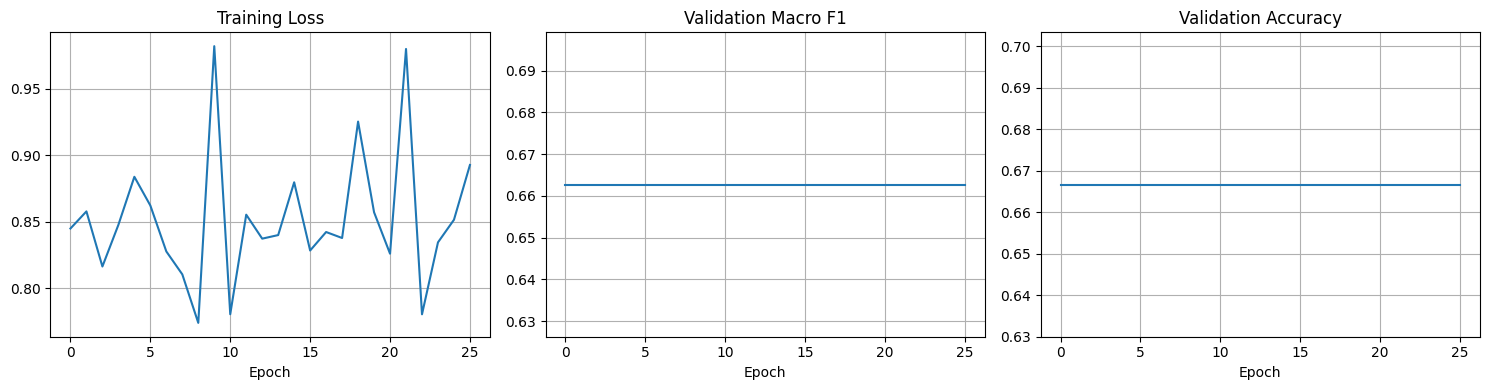

In [133]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(val_f1s)
plt.title('Validation Macro F1')
plt.xlabel('Epoch')
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(val_accs)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.grid(True)
plt.tight_layout()
plt.savefig('training_curves_final.png')
plt.show()


Classification Report on Validation Set:
              precision    recall  f1-score   support

     Organic       0.50      1.00      0.67         1
        Grid       0.60      1.00      0.75         3
      Hybrid       1.00      0.40      0.57         5

    accuracy                           0.67         9
   macro avg       0.70      0.80      0.66         9
weighted avg       0.81      0.67      0.64         9



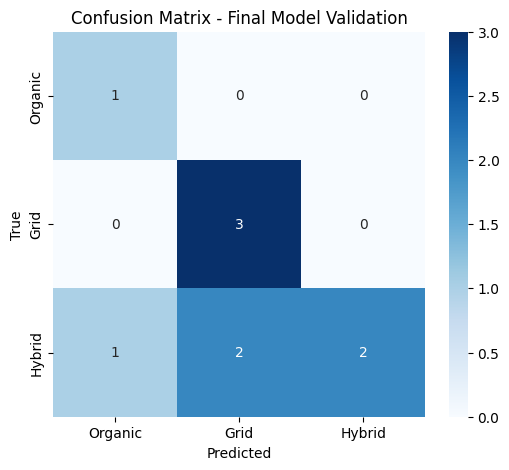

In [135]:
final_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in val_loader_full:
        batch = batch.to(device)
        out = final_model(batch)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

print("\nClassification Report on Validation Set:")
print(classification_report(all_labels, all_preds, target_names=['Organic', 'Grid', 'Hybrid']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Organic','Grid','Hybrid'],
            yticklabels=['Organic','Grid','Hybrid'])
plt.title('Confusion Matrix - Final Model Validation')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_final.png')
plt.show()

# Submission

In [136]:
test_files = sorted(test_path.glob('*.pkl'))
test_files[:4]

[PosixPath('CGCC/data/test/Bangalore_India.pkl'),
 PosixPath('CGCC/data/test/Barcelona_Spain.pkl'),
 PosixPath('CGCC/data/test/Beijing_China.pkl'),
 PosixPath('CGCC/data/test/Belgrade_Serbia.pkl')]

In [137]:
test_data_list = []

In [138]:
for fname in tqdm(test_files, desc="Processing test graphs"):
    with open(fname, 'rb') as f:
        G = pickle.load(f)
    G = nx.convert_node_labels_to_integers(G)

    node_feats = extract_node_feat(G)
    edge_feats = extract_edge_features(G)
    global_feats_raw = extract_graph_feat(G, global_scaler=None)
    global_feats = global_scaler.transform(global_feats_raw.reshape(1,-1)).flatten()

    edges = list(G.edges())
    if len(edges) == 0:
        edge_index = torch.empty((2,0), dtype=torch.long)
        edge_attr = torch.empty((0,3), dtype=torch.float)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_feats, dtype=torch.float)

    data = Data(
        x=torch.tensor(node_feats, dtype=torch.float),
        edge_index=edge_index,
        edge_attr=edge_attr,
        global_feat=torch.tensor(global_feats, dtype=torch.float)
    )
    test_data_list.append(data)


Processing test graphs: 100%|██████████| 36/36 [00:01<00:00, 27.86it/s]


In [139]:
f'Test set {len(test_data_list)} graphs'

'Test set 36 graphs'

In [140]:
test_loader = DataLoader(test_data_list, batch_size=16, shuffle=False)

In [141]:
final_model.eval()
test_preds = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = final_model(batch)
        preds = out.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())

In [142]:
submission = pd.DataFrame({
    'filename': [f.name for f in test_files],
    'target': test_preds
})
submission.to_csv('predictions.csv', index=False)

In [144]:
sub_df = pd.read_csv('predictions.csv')
sub_df.head()

,filename,target
0,Bangalore_India.pkl,2
1,Barcelona_Spain.pkl,2
2,Beijing_China.pkl,1
3,Belgrade_Serbia.pkl,2
4,Boston_Massachusetts_USA.pkl,1


In [131]:
sub_df.shape

(36, 2)